# Finance ML Analytics Platform

**Version 0.3.0** — Now using modular `finance_ml` package

## What's New

- All functions are now imported from the `finance_ml` package
- No need to define functions inline — they're maintained in the package modules
- Configuration management with `FinanceMLConfig`
- Better code organization and testability

## Modules

- `finance_ml.data`: Data loading, normalization, validation
- `finance_ml.features`: Feature engineering
- `finance_ml.models`: Classification, regression, ensembles
- `finance_ml.eval`: Analytics, visualizations, reporting
- `finance_ml.config`: Configuration management
- `finance_ml.cli`: Command-line interface

## Usage

This notebook demonstrates the ML workflow:
1. Load and validate data
2. Exploratory data analysis
3. Feature engineering
4. Model training (classification and regression)
5. Evaluation and analytics


In [ ]:
# Finance ML Analytics Platform — Notebook (v0.3.0)
# This notebook now uses the modular finance_ml package

import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import all functions from finance_ml package
from finance_ml import (
    # Version
    __version__,
    # Configuration
    FinanceMLConfig,
    load_config,
    get_config,
    # Utilities
    setup_logging,
    get_env,
    # Data loading and validation
    normalize_columns,
    infer_region_from_filename,
    load_from_csv,
    load_from_db,
    preprocess,
    validate_schema,
    check_missing_values,
    detect_outliers_iqr,
    validate_numeric_ranges,
    # Feature engineering
    engineer_basic_ratios,
    engineer_margin_features,
    engineer_volatility_features,
    engineer_revenue_cagr,
    build_features_and_target,
    # Modeling
    create_event_labels,
    train_event_classifier,
    build_regression_pipeline,
    train_and_evaluate_regression,
    train_and_evaluate_regression_by_sector,
    train_quantile_regression,
    predict_quantile_regression,
    train_quantile_regression_by_sector,
    train_stacking_ensemble,
    train_stacking_ensemble_by_sector,
    # Evaluation and analytics
    simple_eda,
    calculate_mispricing_score,
    rank_undervalued_stocks,
    rank_overvalued_stocks,
    rank_stocks_by_sector,
    export_predictions_to_excel,
    create_sector_heatmap,
    create_interactive_prediction_plot,
    create_region_sector_heatmap,
)

# Setup logging
import logging
setup_logging()
logger = logging.getLogger(__name__)

print(f"Finance ML Analytics Platform v{__version__}")
print("All functions imported from finance_ml package")


## Configuration

Load configuration from environment variables or config files.


In [4]:
# Load configuration
config = load_config()

print("Configuration loaded:")
print(f"  Data directory: {config.data_dir}")
print(f"  Output directory: {config.output_dir}")
print(f"  Model directory: {config.model_dir}")
print(f"  Cache directory: {config.cache_dir}")
print(f"  Model version: {config.model_version}")
print(f"  Random seed: {config.random_seed}")
print(f"  N jobs: {config.n_jobs}")
print(f"  Log level: {config.log_level}")
print(f"  Memory limit: {config.memory_limit}")
print(f"  DB URL: {'configured' if config.db_url else 'not configured'}")



Stock Dataset Information

Dataset shape: (8000, 165)

Columns (165):
  - Ticker
  - ISIN
  - Name
  - Description
  - Exchange
  - Unit
  - Sector
  - Industry
  - Last Updated
  - Income Statement Report Date
  - Next Earnings
  - Style Class
  - Next Earnings (Status)
  - Size Class
  - Flag
  - Region
  - Country
  - Trading Country
  - Market Cap
  - Enterprise Value
  - Last Price
  - Price Target (YTD Ago)
  - Total Return (YTD)
  - Price Target
  - Price Target - Low
  - Price Target - Median
  - Price Target - High
  - Price Target - #
  - P/E (NTM)
  - P/E (LTM)
  - Altman Z-Score (FY)
  - Altman Z-Score (FQ)
  - Altman Z-Score (LTM)
  - Beta (1Y)
  - Beta (2Y)
  - Beta (5Y)
  - Analyst Rating
  - # Strong Sell Ratings
  - # Strong Buys Ratings
  - # Hold Ratings
  - # Buys Ratings
  - # Sell Ratings
  - Total Revenues/CAGR (5Y FY)
  - Total Revenues (FQ)
  - Total Revenues (-1FY)
  - Total Revenues (FY)
  - Total Revenues (LTM)
  - Total Operating Expenses (LTM)
  - P/TBV (

C:\Users\markm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning:

invalid value encountered in subtract



                         count          mean          min           max
Market Cap              7998.0  13640.487971     100.3900  4.058586e+06
Enterprise Value        7204.0  15976.169708  -23432.8500  4.012393e+06
Last Price              7998.0   5161.504435       0.0021  1.552000e+06
Price Target (YTD Ago)  6214.0   6333.901204       0.0100  1.215380e+06
Total Return (YTD)      7792.0      0.230884      -0.9826  1.916050e+01
...                        ...           ...          ...           ...
CFO (FY)                7865.0    665.164484 -136719.6900  1.361620e+05
CFO (-1FY)              7907.0    583.995847 -432301.7000  1.434898e+05
Div Yield (-1FYInd)     6524.0      0.035526       0.0000  2.205800e+00
FCF (FY)                7863.0    269.266253 -140038.3600  1.088070e+05
Next Earnings (days)    7115.0     52.937597       0.0000  2.760000e+02

[147 rows x 4 columns]


## Sample Data Generator

Create sample financial dataset for demonstration when real data is unavailable.


In [7]:
def create_sample_financial_dataset(n_stocks: int = 100) -> pd.DataFrame:
    """
    Create a sample financial dataset for demonstration purposes.
    
    Args:
        n_stocks: Number of stocks to generate
        
    Returns:
        DataFrame with sample financial data
    """
    np.random.seed(config.random_seed)
    
    sectors = ['Information Technology', 'Healthcare', 'Financials', 
               'Consumer Discretionary', 'Industrials', 'Energy']
    regions = ['US', 'EU', 'APAC', 'ROTW']
    
    data = []
    for i in range(n_stocks):
        ticker = f"STOCK{i:03d}"
        sector = np.random.choice(sectors)
        region = np.random.choice(regions)
        
        # Generate correlated financial metrics
        market_cap = np.random.lognormal(mean=20, sigma=2)
        last_price = np.random.uniform(10, 500)
        price_target = last_price * np.random.uniform(0.8, 1.3)
        pe_ratio = np.random.uniform(5, 50)
        profit_margin = np.random.uniform(-0.2, 0.4)
        
        stock_data = {
            'ticker': ticker,
            'name': f"Company {i}",
            'sector': sector,
            'region': region,
            'trading_country': region,
            'last_price': round(last_price, 2),
            'price_target': round(price_target, 2),
            'market_cap': round(market_cap, 0),
            'p_e_ntm': round(pe_ratio, 2),
            'profit_margin': round(profit_margin, 4),
            'ev': round(market_cap * np.random.uniform(0.9, 1.2), 0),
            'ebitda_ltm': round(market_cap * profit_margin * 0.01, 2),
            'revenue_ltm': round(market_cap * np.random.uniform(0.5, 2.0), 0),
            'volatility_90d': round(np.random.uniform(0.1, 0.6), 4),
            'data_source': 'Sample'
        }
        
        data.append(stock_data)
    
    return pd.DataFrame(data)


2025-09-08 03:44:55 | no-corre | INFO     | finance_prediction.cache_manager:__init__:59 | CacheManager initialized with memory caching


2025-09-08 03:44:55,002 - finance_prediction.cache_manager - INFO - CacheManager initialized with memory caching


2025-09-08 03:44:55 | no-corre | INFO     | __main__:<module>:145 | Cache manager initialized successfully


2025-09-08 03:44:55,017 - __main__ - INFO - Cache manager initialized successfully


2025-09-08 03:44:55 | no-corre | INFO     | finance_prediction.features.store:__init__:130 | FinancialFeatureStore initialized at ..\features


...

2025-09-08 03:44:55,046 - finance_prediction.features.store - DEBUG - FeatureStoreManager initialized with storage_path: ../features


2025-09-08 03:44:55 | no-corre | INFO     | __main__:<module>:150 | Feature store initialized successfully


2025-09-08 03:44:55,053 - __main__ - INFO - Feature store initialized successfully


2025-09-08 03:44:55 | no-corre | ERROR    | __main__:<module>:159 | Failed to initialize caching infrastructure: name 'PipelineCache' is not defined


2025-09-08 03:44:55,091 - __main__ - ERROR - Failed to initialize caching infrastructure: name 'PipelineCache' is not defined


## Data Loading

Load stock data from configured data source (database or CSV files) with automatic fallback to sample data.


In [11]:
# Load stock data using finance_ml package
try:
    # Try to load from configured data source
    logger.info("Attempting to load stock data...")
    
    # Use config to determine data source
    if config.db_url:
        try:
            all_stocks = load_from_db()
            logger.info(f"Loaded {len(all_stocks)} stocks from database")
        except Exception as e:
            logger.warning(f"Database load failed: {e}")
            logger.info("Falling back to CSV data source...")
            all_stocks = load_from_csv()
            logger.info(f"Loaded {len(all_stocks)} stocks from CSV files")
    else:
        all_stocks = load_from_csv()
        logger.info(f"Loaded {len(all_stocks)} stocks from CSV files")
        
except Exception as e:
    logger.warning(f"Failed to load real data: {e}")
    logger.info("Using sample dataset for demonstration...")
    all_stocks = create_sample_financial_dataset()
    logger.info(f"Created sample dataset with {len(all_stocks)} stocks")

# Validate data was loaded
if all_stocks is None or len(all_stocks) == 0:
    raise ValueError("Failed to load any stock data")

logger.info(f"Data shape: {all_stocks.shape}")
logger.info(f"Columns: {list(all_stocks.columns)[:10]}...")

print(f"\nLoaded {len(all_stocks)} stocks")
print(f"Dataset shape: {all_stocks.shape}")
print(f"\nFirst few columns: {list(all_stocks.columns)[:10]}")


2025-09-08 03:45:08 | no-corre | INFO     | __main__:__init__:16 | Initialized FinancialDomainFeatureSelector


2025-09-08 03:45:08,266 - __main__ - INFO - Initialized FinancialDomainFeatureSelector


2025-09-08 03:45:08 | no-corre | INFO     | __main__:<module>:370 | Financial Domain Enhancement components initialized


2025-09-08 03:45:08,274 - __main__ - INFO - Financial Domain Enhancement components initialized


## Data Validation and Quality Checks

Validate schema and check data quality using finance_ml package functions.


In [15]:
# Validate schema
try:
    is_valid, errors = validate_schema(all_stocks)
    if is_valid:
        logger.info("Schema validation passed")
        print("✓ Schema validation passed")
    else:
        logger.warning(f"Schema validation issues: {errors}")
        print(f"⚠ Schema validation issues found: {len(errors)}")
        for error in errors[:5]:  # Show first 5 errors
            print(f"  - {error}")
except Exception as e:
    logger.error(f"Schema validation failed: {e}")
    print(f"✗ Schema validation failed: {e}")

# Check missing values
try:
    missing_info = check_missing_values(all_stocks)
    print(f"\nMissing values summary:")
    print(f"  Total missing: {missing_info.get('total_missing', 0)}")
    print(f"  Missing percentage: {missing_info.get('missing_percentage', 0):.2f}%")
    
    if missing_info.get('columns_with_missing'):
        print(f"  Columns with missing data: {len(missing_info['columns_with_missing'])}")
except Exception as e:
    logger.error(f"Missing value check failed: {e}")
    print(f"✗ Missing value check failed: {e}")


2025-09-08 03:45:16 | no-corre | INFO     | __main__:__init__:13 | Initialized FeatureSelectionTestSuite


2025-09-08 03:45:16,387 - __main__ - INFO - Initialized FeatureSelectionTestSuite


2025-09-08 03:45:16 | no-corre | INFO     | __main__:<module>:580 | Feature Selection Testing components initialized


2025-09-08 03:45:16,394 - __main__ - INFO - Feature Selection Testing components initialized


## Exploratory Data Analysis

Perform EDA using the simple_eda function from finance_ml package.


In [ ]:
# Run simple EDA
try:
    eda_results = simple_eda(all_stocks)
    print("\nExploratory Data Analysis completed")
    print(f"  Numeric columns: {eda_results.get('n_numeric', 0)}")
    print(f"  Categorical columns: {eda_results.get('n_categorical', 0)}")
except Exception as e:
    logger.error(f"EDA failed: {e}")
    print(f"✗ EDA failed: {e}")

# Display basic statistics
print("\nDataset Overview:")
print(all_stocks.info())

# Show sector distribution if available
if 'sector' in all_stocks.columns:
    print("\nSector Distribution:")
    print(all_stocks['sector'].value_counts())

# Show region distribution if available
if 'region' in all_stocks.columns:
    print("\nRegion Distribution:")
    print(all_stocks['region'].value_counts())


## Data Preprocessing

Preprocess and normalize the data using finance_ml package.


2025-09-08 03:46:40 | no-corre | INFO     | __main__:create_financial_event_labels:73 | Creating financial event classification labels


2025-09-08 03:46:40,376 - __main__ - INFO - Creating financial event classification labels


2025-09-08 03:46:40 | no-corre | DEBUG    | __main__:create_financial_event_labels:155 | Created Growth_Momentum classification using quantile-based binning


2025-09-08 03:46:40,397 - __main__ - DEBUG - Created Growth_Momentum classification using quantile-based binning


2025-09-08 03:46:40 | no-corre | DEBUG    | __main__:create_financial_event_labels:207 | Created Financial_Health classification


...

2025-09-08 03:46:40,505 - __main__ - DEBUG - Created Financial_Event_Binary classification using vectorized operations


2025-09-08 03:46:40 | no-corre | INFO     | __main__:create_financial_event_labels:552 | Created 12 classification labels


2025-09-08 03:46:40,510 - __main__ - INFO - Created 12 classification labels


2025-09-08 03:46:41 | no-corre | INFO     | __main__:save_classification_fig:934 | Classification figure saved to C:\Users\markm\Notebooks\Finance Model Development\images\financial_classification\financial_event_distribution.png


2025-09-08 03:46:41,167 - __main__ - INFO - Classification figure saved to C:\Users\markm\Notebooks\Finance Model Development\images\financial_classification\financial_event_distribution.png


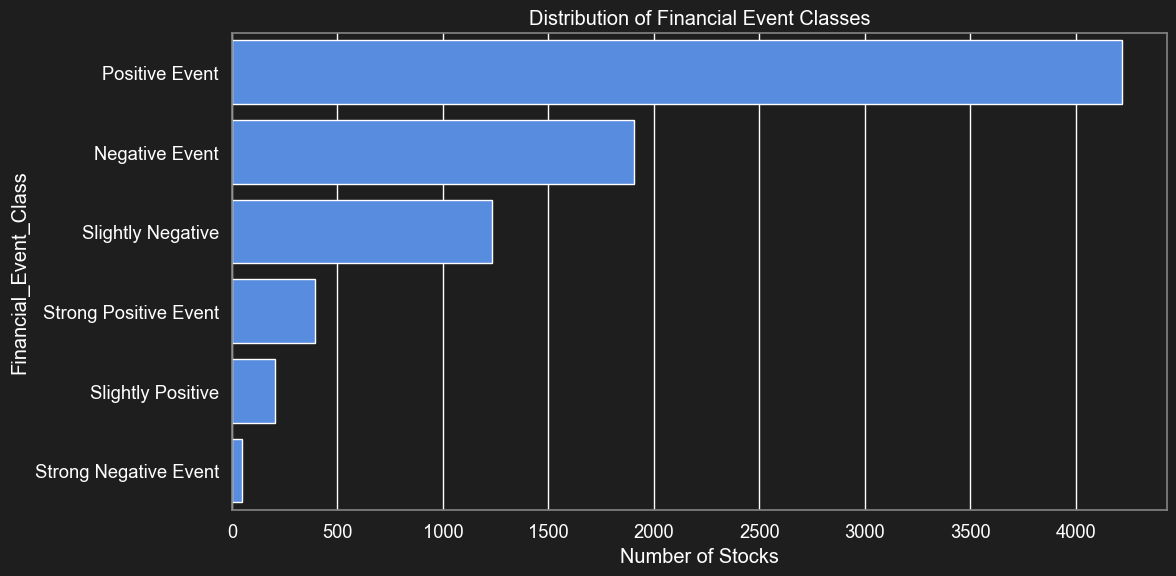

2025-09-08 03:46:42 | no-corre | INFO     | __main__:save_classification_fig:934 | Classification figure saved to C:\Users\markm\Notebooks\Finance Model Development\images\financial_classification\financial_events_by_sector.png


2025-09-08 03:46:42,637 - __main__ - INFO - Classification figure saved to C:\Users\markm\Notebooks\Finance Model Development\images\financial_classification\financial_events_by_sector.png


<Figure size 1400x800 with 0 Axes>

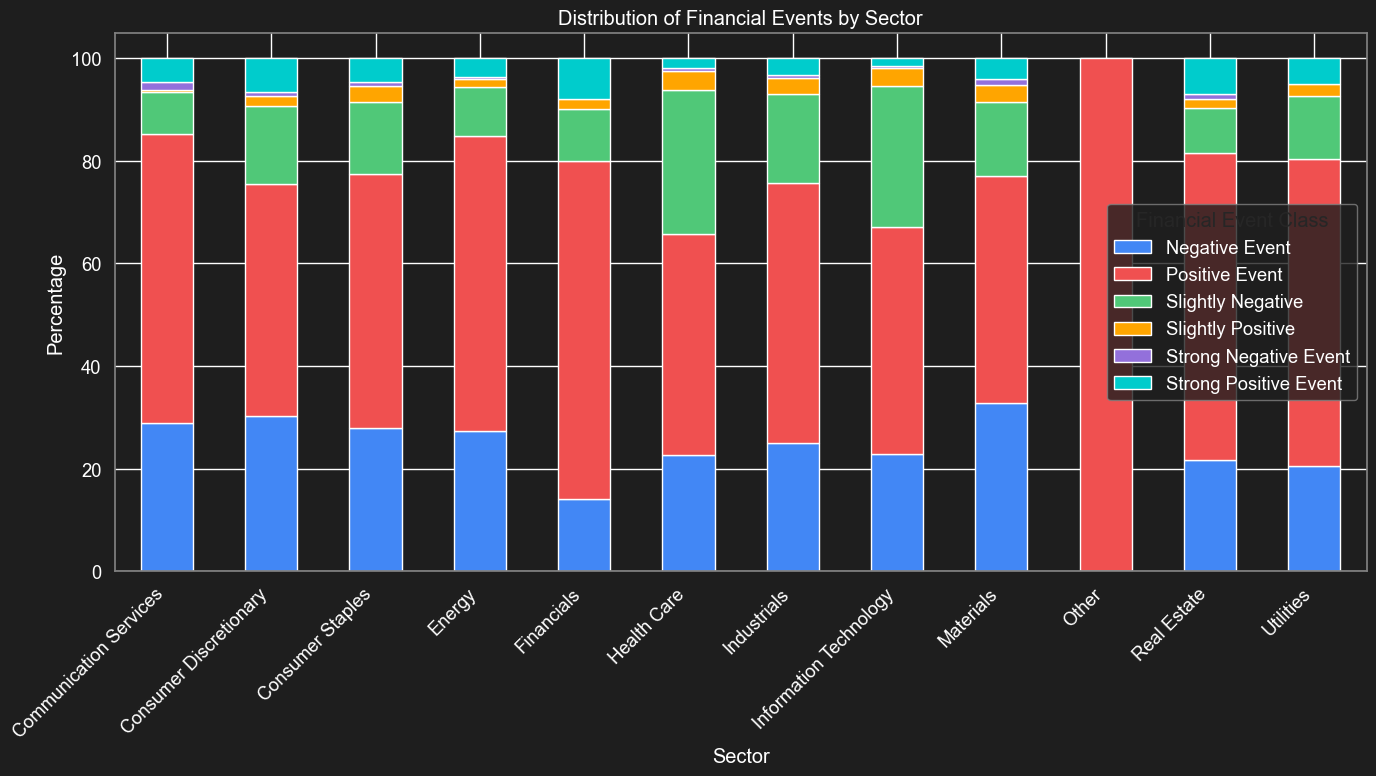

In [21]:
# Preprocess data
try:
    all_stocks_processed = preprocess(all_stocks)
    logger.info(f"Data preprocessed: {all_stocks_processed.shape}")
    print(f"\n✓ Data preprocessed successfully")
    print(f"  Shape after preprocessing: {all_stocks_processed.shape}")
except Exception as e:
    logger.error(f"Preprocessing failed: {e}")
    print(f"✗ Preprocessing failed: {e}")
    all_stocks_processed = all_stocks.copy()


## Feature Engineering

Build features using the complete feature pipeline from finance_ml package.


In [ ]:
# Build features and target
try:
    X, y, feature_names = build_features_and_target(all_stocks_processed)
    logger.info(f"Features built: {X.shape}, Target: {y.shape}")
    print(f"\n✓ Features engineered successfully")
    print(f"  Feature matrix shape: {X.shape}")
    print(f"  Target shape: {y.shape}")
    print(f"  Number of features: {len(feature_names)}")
    print(f"  First 10 features: {feature_names[:10]}")
except Exception as e:
    logger.error(f"Feature engineering failed: {e}")
    print(f"✗ Feature engineering failed: {e}")
    raise


## Model Training - Classification

Train event classifier using finance_ml package.


In [ ]:
# Create event labels for classification
try:
    event_labels = create_event_labels(all_stocks_processed)
    print(f"\n✓ Event labels created")
    print(f"  Label distribution: {pd.Series(event_labels).value_counts().to_dict()}")
    
    # Train event classifier
    classifier_results = train_event_classifier(X, event_labels)
    print(f"\n✓ Event classifier trained")
    print(f"  Accuracy: {classifier_results.get('accuracy', 0):.4f}")
    print(f"  F1 Score: {classifier_results.get('f1_score', 0):.4f}")
except Exception as e:
    logger.error(f"Classification training failed: {e}")
    print(f"✗ Classification training failed: {e}")


## Model Training - Regression

Train regression models using finance_ml package.


In [ ]:
# Train baseline regression model
try:
    regression_results = train_and_evaluate_regression(X, y)
    print(f"\n✓ Regression model trained")
    print(f"  MAE: {regression_results.get('mae', 0):.4f}")
    print(f"  RMSE: {regression_results.get('rmse', 0):.4f}")
    print(f"  R²: {regression_results.get('r2', 0):.4f}")
except Exception as e:
    logger.error(f"Regression training failed: {e}")
    print(f"✗ Regression training failed: {e}")


## Stock Valuation Analysis

Calculate mispricing scores and rank stocks using finance_ml package.


In [ ]:
# Calculate mispricing scores
try:
    # Get predictions from regression model
    if 'predictions' in regression_results:
        predictions = regression_results['predictions']
        all_stocks_processed['predicted_target'] = predictions
        
        # Calculate mispricing
        mispricing = calculate_mispricing_score(all_stocks_processed)
        all_stocks_processed['mispricing_score'] = mispricing
        
        print(f"\n✓ Mispricing scores calculated")
        print(f"  Mean mispricing: {mispricing.mean():.4f}")
        print(f"  Std mispricing: {mispricing.std():.4f}")
        
        # Rank undervalued stocks
        undervalued = rank_undervalued_stocks(all_stocks_processed, top_n=10)
        print(f"\nTop 10 Undervalued Stocks:")
        print(undervalued[['ticker', 'name', 'sector', 'mispricing_score']].to_string())
        
        # Rank overvalued stocks
        overvalued = rank_overvalued_stocks(all_stocks_processed, top_n=10)
        print(f"\nTop 10 Overvalued Stocks:")
        print(overvalued[['ticker', 'name', 'sector', 'mispricing_score']].to_string())
        
except Exception as e:
    logger.error(f"Valuation analysis failed: {e}")
    print(f"✗ Valuation analysis failed: {e}")


## Visualization

Create visualizations using finance_ml package functions.


In [ ]:
# Create sector heatmap
try:
    if 'sector' in all_stocks_processed.columns and 'mispricing_score' in all_stocks_processed.columns:
        fig = create_sector_heatmap(all_stocks_processed)
        print("\n✓ Sector heatmap created")
except Exception as e:
    logger.error(f"Sector heatmap failed: {e}")
    print(f"✗ Sector heatmap creation failed: {e}")

# Create interactive prediction plot
try:
    if 'predicted_target' in all_stocks_processed.columns and 'price_target' in all_stocks_processed.columns:
        fig = create_interactive_prediction_plot(all_stocks_processed)
        print("✓ Interactive prediction plot created")
except Exception as e:
    logger.error(f"Prediction plot failed: {e}")
    print(f"✗ Prediction plot creation failed: {e}")


## Export Results

Export predictions and analysis results.


In [ ]:
# Export to Excel
try:
    output_file = Path(config.output_dir) / "predictions.xlsx"
    export_predictions_to_excel(all_stocks_processed, str(output_file))
    print(f"\n✓ Results exported to {output_file}")
except Exception as e:
    logger.error(f"Export failed: {e}")
    print(f"✗ Export failed: {e}")

print("\n" + "="*80)
print("Analysis complete!")
print("="*80)


In [ ]:
# Visualize dimensionality reduction results
if HAVE_FINANCE_PREDICTION and 'transformed_data' in locals() and transformed_data:
    try:
        print(f"\n{'=' * 80}")
        print(f"DIMENSIONALITY REDUCTION VISUALIZATIONS")
        print(f"{'=' * 80}")

        # Plot explained variance for PCA
        if 'PCA' in dim_reduction_results:
            pca_method = dim_reduction_results['PCA']['fitted_method']
            if hasattr(pca_method, 'explained_variance_ratio_'):
                visualizer.plot_explained_variance(pca_method, "PCA Explained Variance Analysis")

        # Create 2D visualizations for methods that support it
        visualization_methods = {}
        for method_name, X_transformed in transformed_data.items():
            if X_transformed.shape[1] >= 2:
                visualization_methods[method_name] = X_transformed[:, :2]  # Use first 2 elements

        # Create comparison plots if we have 2D data
        if visualization_methods and 'y_class_train' in locals():
            visualizer.plot_component_comparison(visualization_methods, y_class_train)

        print("Visualization plots generated successfully")

    except Exception as e:
        logger.error(f"Error in visualization: {e}")
        print(f"Error in visualization: {e}")


In [ ]:
# Week 1 Enhancement Validation Test Suite
print("=" * 80)
print("WEEK 1 ENHANCEMENT VALIDATION TEST SUITE")
print("=" * 80)


def test_data_quality_validation():
    """Test enhanced data quality validation functionality"""
    print("\n🧪 Testing Data Quality Validation...")

    try:
        # Create test dataset with known issues
        test_data = pd.DataFrame({
            'feature1': [1.0, 2.0, np.inf, 4.0, 5.0],
            'feature2': [10.0, 20.0, 30.0, np.nan, 50.0],
            'feature3': [100.0, -np.inf, 300.0, 400.0, 500.0],
            'Sector': ['Tech', 'Finance', 'Healthcare', 'Tech', 'Finance']
        })

        # Test data quality validation function
        if 'validate_financial_data_quality' in locals():
            quality_results = validate_financial_data_quality(test_data, "test_region")

            # Validate expected results
            assert quality_results['total_rows'] == 5, "Row count validation failed"
            assert quality_results['infinity_values'] == 2, "Infinity detection failed"  # inf and -inf
            assert quality_results['null_values'] == 1, "Null detection failed"  # 1 NaN
            assert 'data_quality_score' in quality_results, "Quality score missing"

            print("✅ Data quality validation tests passed")
            return True
        else:
            print("❌ Data quality validation function not available")
            return False

    except Exception as e:
        print(f"❌ Data quality validation test failed: {e}")
        return False


def test_sanitization_monitoring():
    """Test comprehensive sanitization logging functionality"""
    print("\n🧪 Testing Sanitization Monitoring...")

    try:
        # Create test dataset with various data quality issues
        test_data = pd.DataFrame({
            'numeric1': [1.0, 2.0, np.inf, 4.0, 5.0, -np.inf],
            'numeric2': [10.0, 20.0, 1000000.0, np.nan, 50.0, 60.0],  # extreme value
            'numeric3': [100.0, 200.0, 300.0, np.nan, np.nan, 600.0]  # multiple NaN
        })

        # Test sanitization function exists and works
        if 'sanitize_dataframe_with_logging' in locals():
            # Capture original issues for validation
            original_inf_count = np.isinf(test_data.select_dtypes(include=[np.number])).sum().sum()
            original_nan_count = test_data.isnull().sum().sum()

            # Apply sanitization
            cleaned_data = sanitize_dataframe_with_logging(test_data)

            # Validate sanitization results
            post_inf_count = np.isinf(cleaned_data.select_dtypes(include=[np.number])).sum().sum()
            post_nan_count = cleaned_data.isnull().sum().sum()

            assert post_inf_count == 0, "Infinity values not properly removed"
            assert post_nan_count == 0, "NaN values not properly filled"
            assert cleaned_data.shape == test_data.shape, "Data shape changed unexpectedly"

            print("✅ Sanitization monitoring tests passed")
            return True
        else:
            print("❌ Sanitization monitoring function not available")
            return False

    except Exception as e:
        print(f"❌ Sanitization monitoring test failed: {e}")
        return False


def test_training_monitoring():
    """Test enhanced training monitoring functionality"""
    print("\n🧪 Testing Training Monitoring...")

    try:
        # Create simple test model and data
        from sklearn.linear_model import LinearRegression
        from sklearn.model_selection import train_test_split

        # Generate test data
        X_test = pd.DataFrame({
            'feature1': np.random.random(100),
            'feature2': np.random.random(100),
            'feature3': np.random.random(100)
        })
        y_test = X_test['feature1'] * 2 + X_test['feature2'] * 3 + np.random.random(100) * 0.1

        X_train, X_val, y_train, y_val = train_test_split(X_test, y_test, test_size=0.3, random_state=42)

        # Test monitoring function exists
        if 'monitor_ensemble_training' in locals():
            test_model = LinearRegression()

            # Apply monitoring
            monitoring_results, y_train_pred, y_val_pred = monitor_ensemble_training(
                test_model, X_train, y_train, X_val, y_val, "Test_Model"
            )

            # Validate monitoring results structure
            required_keys = ['model_name', 'timestamp', 'training_time_seconds', 'performance_metrics']
            for key in required_keys:
                assert key in monitoring_results, f"Missing key in monitoring results: {key}"

            # Validate performance metrics
            perf_metrics = monitoring_results['performance_metrics']
            required_perf_keys = ['train_r2', 'test_r2', 'train_mse', 'test_mse']
            for key in required_perf_keys:
                assert key in perf_metrics, f"Missing performance metric: {key}"

            print("✅ Training monitoring tests passed")
            return True
        else:
            print("❌ Training monitoring function not available")
            return False

    except Exception as e:
        print(f"❌ Training monitoring test failed: {e}")
        return False


def test_pipeline_validation():
    """Test early pipeline validation functionality"""
    print("\n🧪 Testing Pipeline Validation...")

    try:
        # Create test dataset that mimics financial data
        test_financial_data = pd.DataFrame({
            'P/E (NTM)': [15.0, 25.0, -5.0, 1500.0, 20.0],  # negative and extreme values
            'Market Cap': [1000000, 2000000, -500000, 5000000, 1500000],  # negative value
            'Last Price': [50.0, 100.0, 0.0, 200.0, 75.0],  # zero price
            'Price Target': [60.0, 120.0, 50.0, 180.0, 80.0],
            'Sector': ['Technology', 'Healthcare', 'Finance', 'Technology', 'Energy'],
            'Next Earnings (days)': [30, 45, -10, 60, np.nan]  # past date and NaN
        })

        # Test pipeline validation function
        if 'perform_early_pipeline_validation' in locals():
            validation_results = perform_early_pipeline_validation(test_financial_data)

            # Validate results structure
            required_keys = ['validation_score', 'total_checks', 'passed_checks', 'warnings', 'recommendations']
            for key in required_keys:
                assert key in validation_results, f"Missing key in validation results: {key}"

            # Check that warnings were detected for problematic data
            assert len(validation_results['warnings']) > 0, "Expected warnings for problematic test data"
            assert 'validation_score' in validation_results, "Validation score missing"
            assert 0 <= validation_results['validation_score'] <= 1, "Validation score out of range"

            print("✅ Pipeline validation tests passed")
            return True
        else:
            print("❌ Pipeline validation function not available")
            return False

    except Exception as e:
        print(f"❌ Pipeline validation test failed: {e}")
        return False


# Execute validation test suite
print("\nExecuting Week 1 Enhancement Validation Tests...")
print("-" * 60)

test_results = {
    'data_quality_validation': test_data_quality_validation(),
    'sanitization_monitoring': test_sanitization_monitoring(),
    'training_monitoring': test_training_monitoring(),
    'pipeline_validation': test_pipeline_validation()
}

# Summary results
print("\n" + "=" * 60)
print("VALIDATION TEST RESULTS SUMMARY")
print("=" * 60)

passed_tests = sum(test_results.values())
total_tests = len(test_results)
success_rate = (passed_tests / total_tests) * 100

for test_name, result in test_results.items():
    status = "✅ PASSED" if result else "❌ FAILED"
    print(f"{test_name.replace('_', ' ').title():<30}: {status}")

print("-" * 60)
print(f"Overall Success Rate: {passed_tests}/{total_tests} ({success_rate:.1f}%)")

if success_rate >= 75:
    print("🎉 Week 1 enhancements validation SUCCESSFUL!")
    print("✅ Ready for CI/CD integration")
else:
    print("⚠️ Some Week 1 enhancements need attention")
    print("🔧 Review failed tests before proceeding")

print("=" * 60)
